In [1]:
# Setup & Font Config
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_score, recall_score, f1_score, accuracy_score)
import seaborn as sns
import time, os

# Install Liberation Serif (Times New Roman substitute) if not present
!apt-get install -y fonts-liberation -qq > /dev/null

# Matplotlib global config — 600 DPI, Liberation Serif, size 14 bold axes
mpl.rcParams['font.family'] = 'Liberation Serif'
mpl.rcParams['font.size'] = 14
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['savefig.dpi'] = 600
mpl.rcParams['figure.dpi'] = 600

os.makedirs('figures', exist_ok=True)

def save_fig(fig, name):
    """Save figure as both EPS and PDF at 600 DPI."""
    fig.savefig(f'figures/{name}.eps', format='eps', dpi=600, bbox_inches='tight')
    fig.savefig(f'figures/{name}.pdf', format='pdf', dpi=600, bbox_inches='tight')
    print(f"Saved: figures/{name}.eps and figures/{name}.pdf")

print("TensorFlow version:", tf.__version__)
print("GPU Available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Task 1: Dataset Preparation
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print(f"Training data shape: {x_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Testing data shape: {x_test.shape}")
print(f"Testing labels shape: {y_test.shape}")

class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Normalize pixel values to [0,1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Training set: {x_train_norm.shape[0]} images")
print(f"Testing set: {x_test_norm.shape[0]} images")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 923s 5us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Testing data shape: (10000, 32, 32, 3)
Testing labels shape: (10000, 1)
Training set: 50000 images
Testing set: 10000 images


Saved: figures/fig1_sample_images.eps and figures/fig1_sample_images.pdf


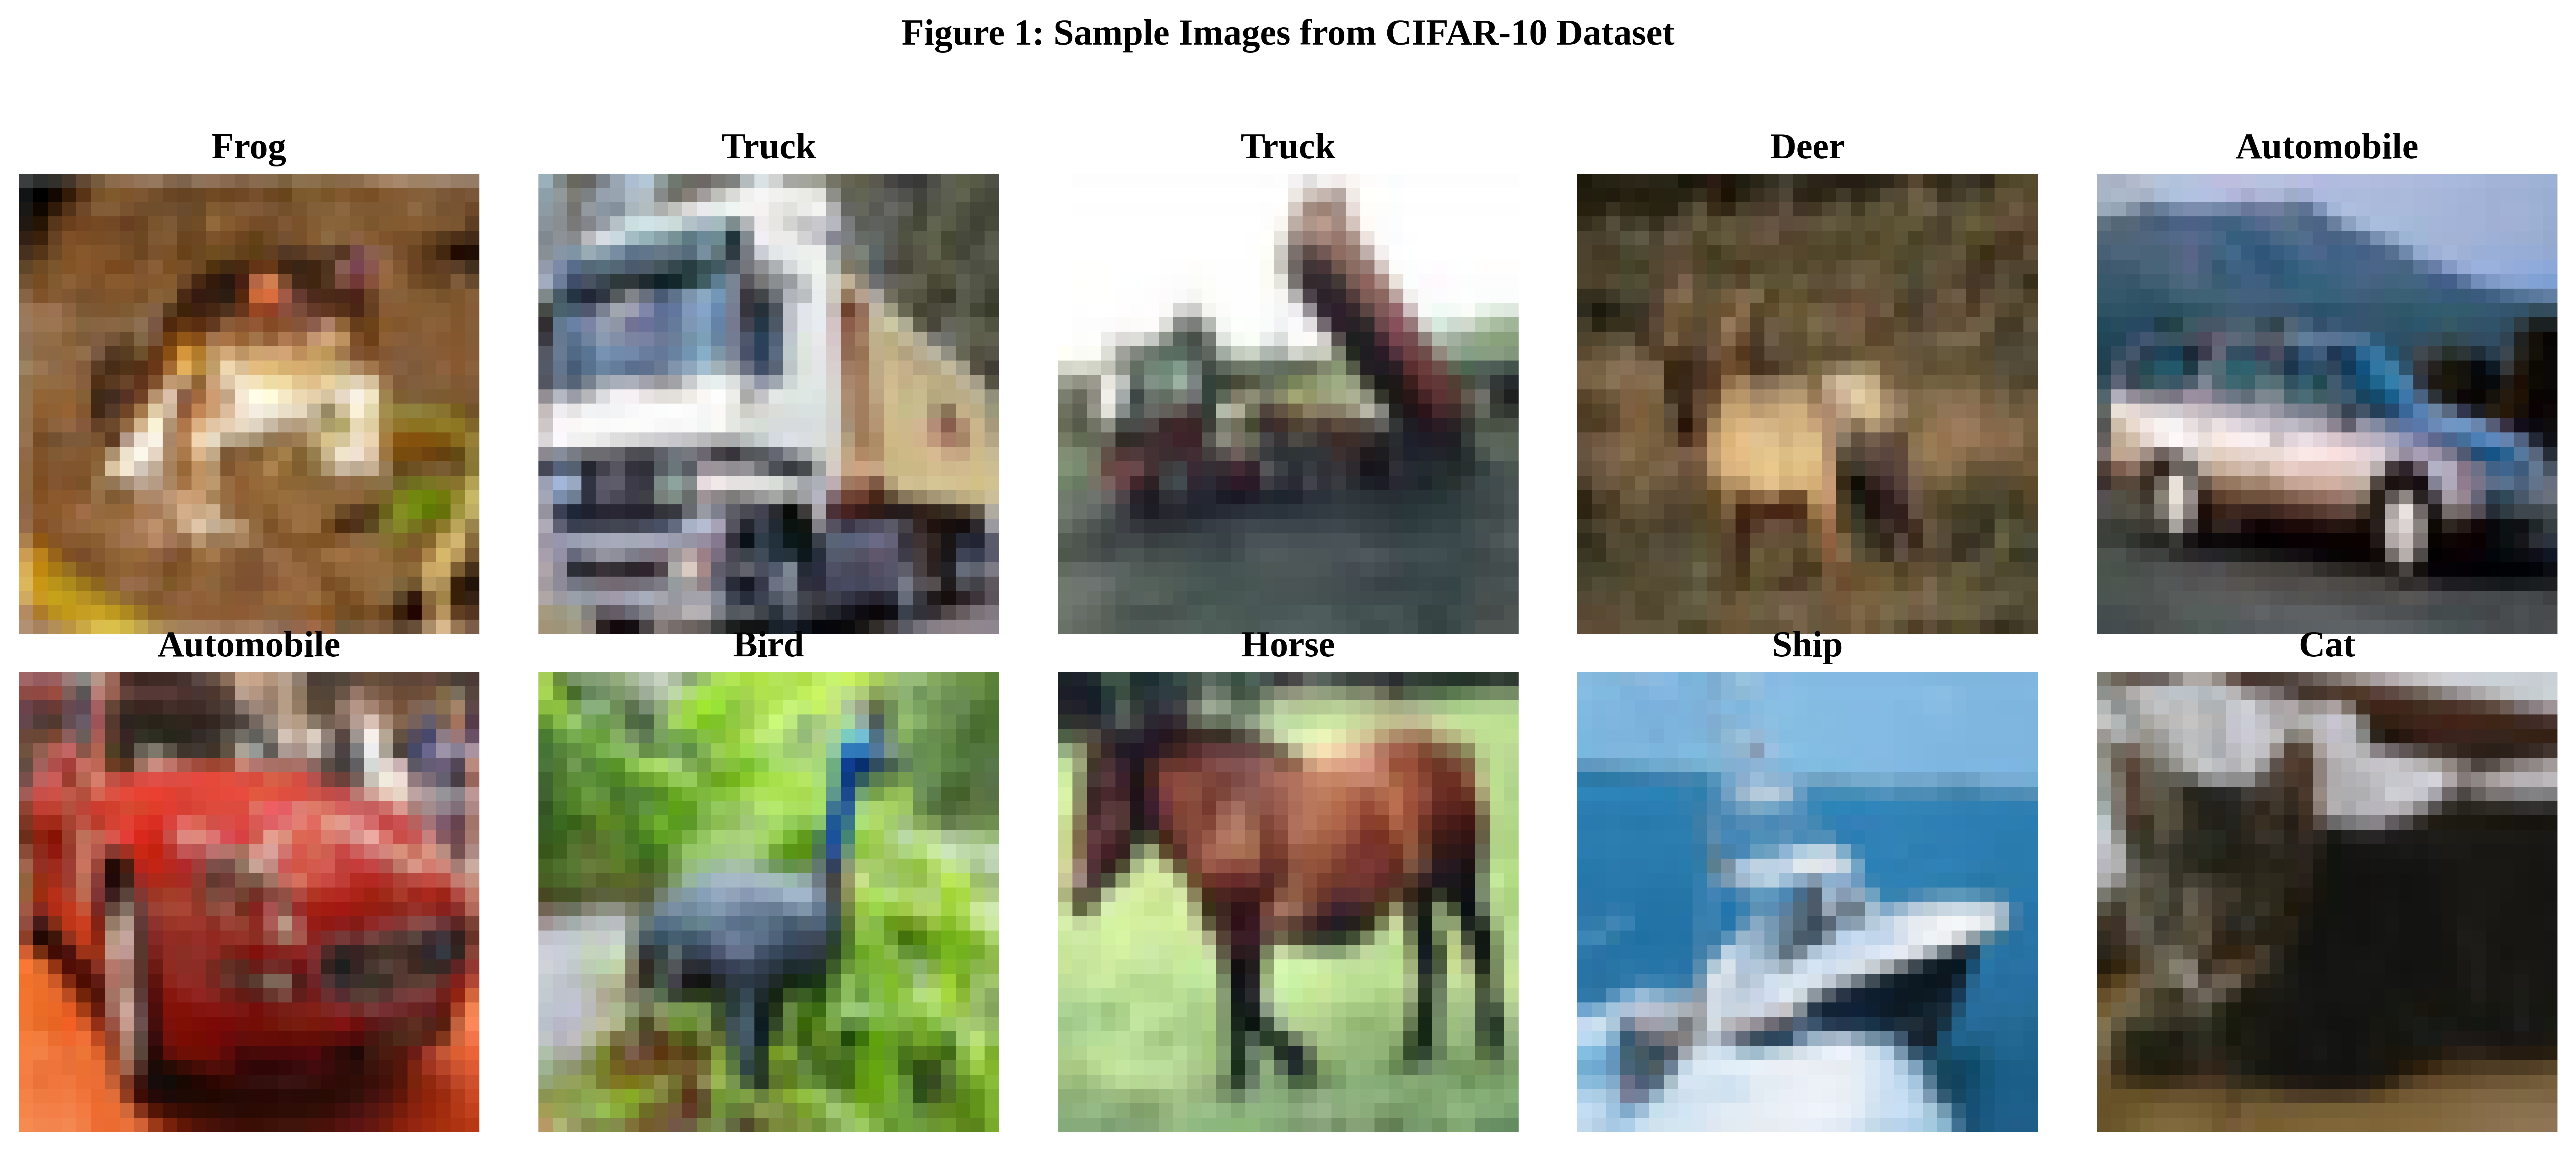


Caption — Figure 1: Sample CIFAR-10 Images
Inference: The dataset contains 32x32 RGB images across 10 balanced classes, showing sufficient visual diversity for classification but low resolution poses a challenge for feature extraction.


In [3]:
# Figure 1: Sample CIFAR-10 Images
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train[i][0]], fontsize=14, fontweight='bold')
    ax.axis('off')

fig.suptitle('Figure 1: Sample Images from CIFAR-10 Dataset', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
save_fig(fig, 'fig1_sample_images')
plt.show()

print("\nCaption — Figure 1: Sample CIFAR-10 Images")
print("Inference: The dataset contains 32x32 RGB images across 10 balanced classes, "
      "showing sufficient visual diversity for classification but low resolution poses "
      "a challenge for feature extraction.")

In [4]:
# Task 2: Transfer Learning Model (VGG16)
# Load pretrained VGG16 with ImageNet weights, exclude top classifier
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

# Freeze convolutional base
base_model.trainable = False

# Build classifier head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
output = Dense(10, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

total_params = model.count_params()
print(f"\nTotal Parameters: {total_params:,}")

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)


Total Parameters: 14,848,586


In [5]:
# Task 3: Model Training
start_time = time.time()

history = model.fit(
    x_train_norm, y_train_cat,
    validation_data=(x_test_norm, y_test_cat),
    batch_size=32,
    epochs=15,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining Time: {training_time:.2f} seconds ({training_time/60:.2f} minutes)")

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.5297 - loss: 1.3449 - val_accuracy: 0.5710 - val_loss: 1.2255
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.5929 - loss: 1.1672 - val_accuracy: 0.5757 - val_loss: 1.2030
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6118 - loss: 1.1050 - val_accuracy: 0.5922 - val_loss: 1.1623
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6307 - loss: 1.0536 - val_accuracy: 0.5965 - val_loss: 1.1409
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.6442 - loss: 1.0113 - val_accuracy: 0.5991 - val_loss: 1.1403
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6576 - loss: 0.9725 - val_accuracy: 0.6093 - val_loss: 1.1318
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6693 - loss: 0.9404 - val_accuracy: 0.6132 - val_loss: 1.1160
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.6806 - los

Saved: figures/fig2_accuracy.eps and figures/fig2_accuracy.pdf


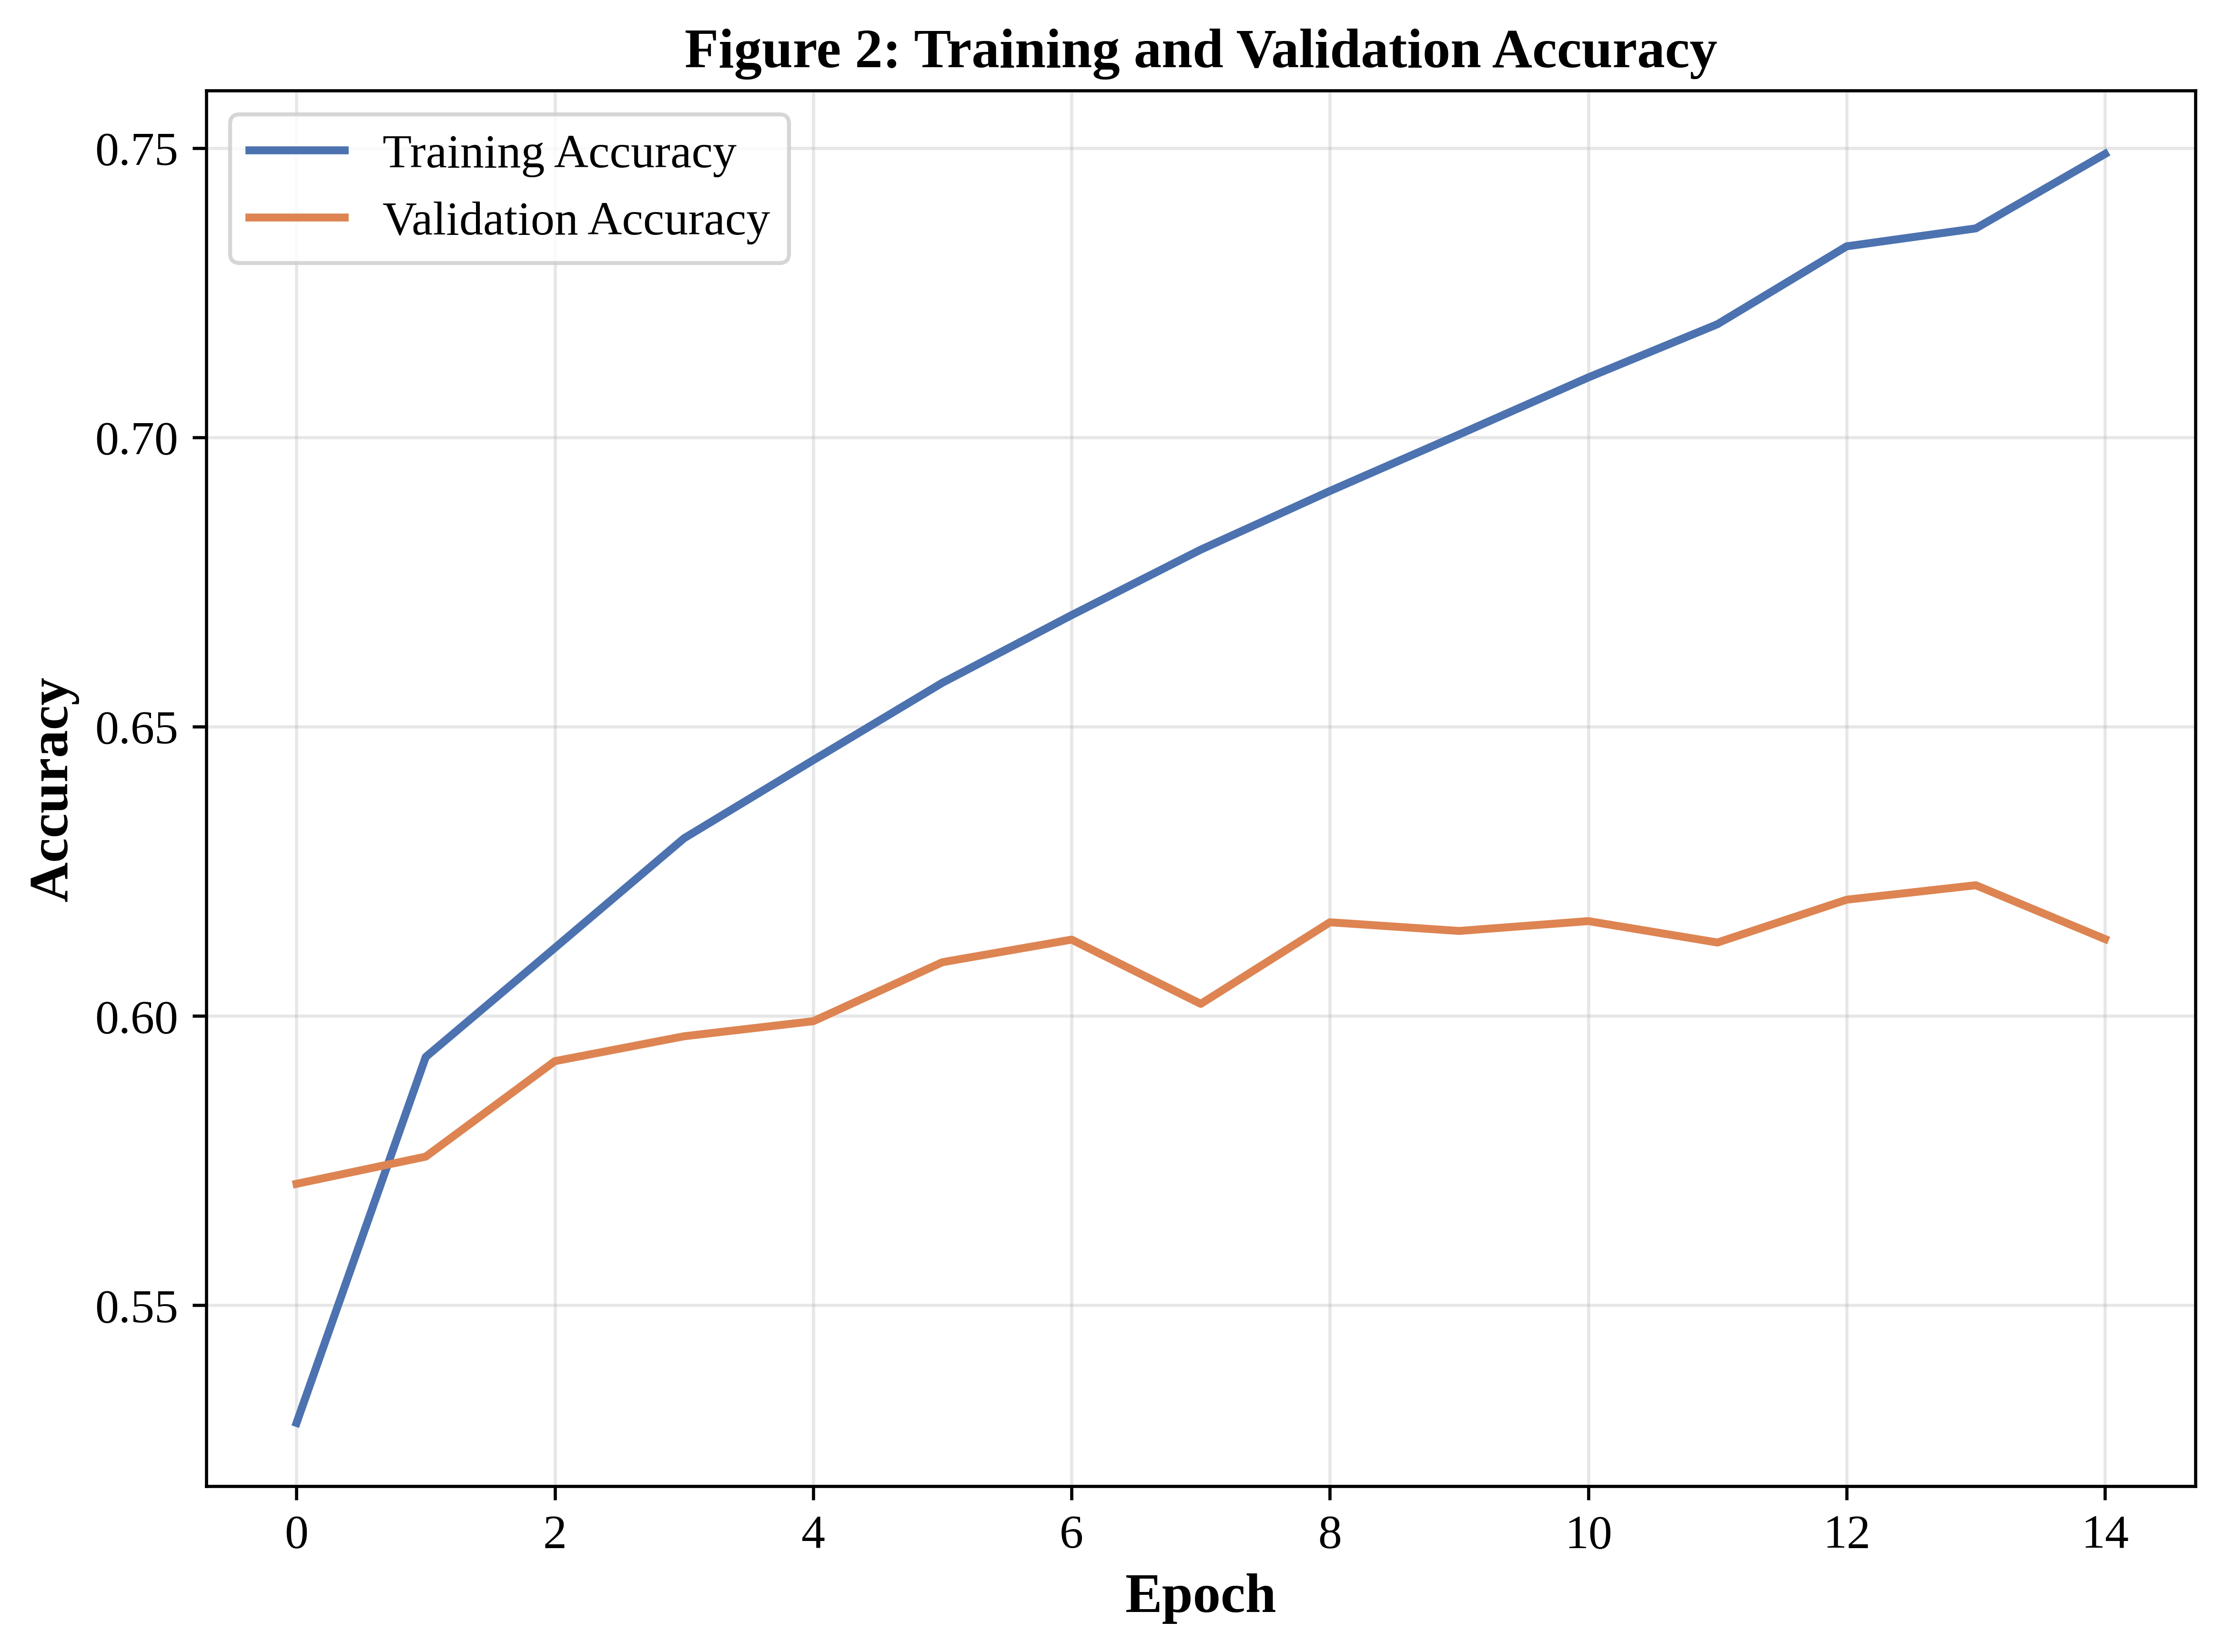


Caption — Figure 2: Training and Validation Accuracy vs Epochs
Inference: Training accuracy increases steadily while validation accuracy trends closely with it, indicating the pretrained features generalize well without severe overfitting.


Saved: figures/fig3_loss.eps and figures/fig3_loss.pdf


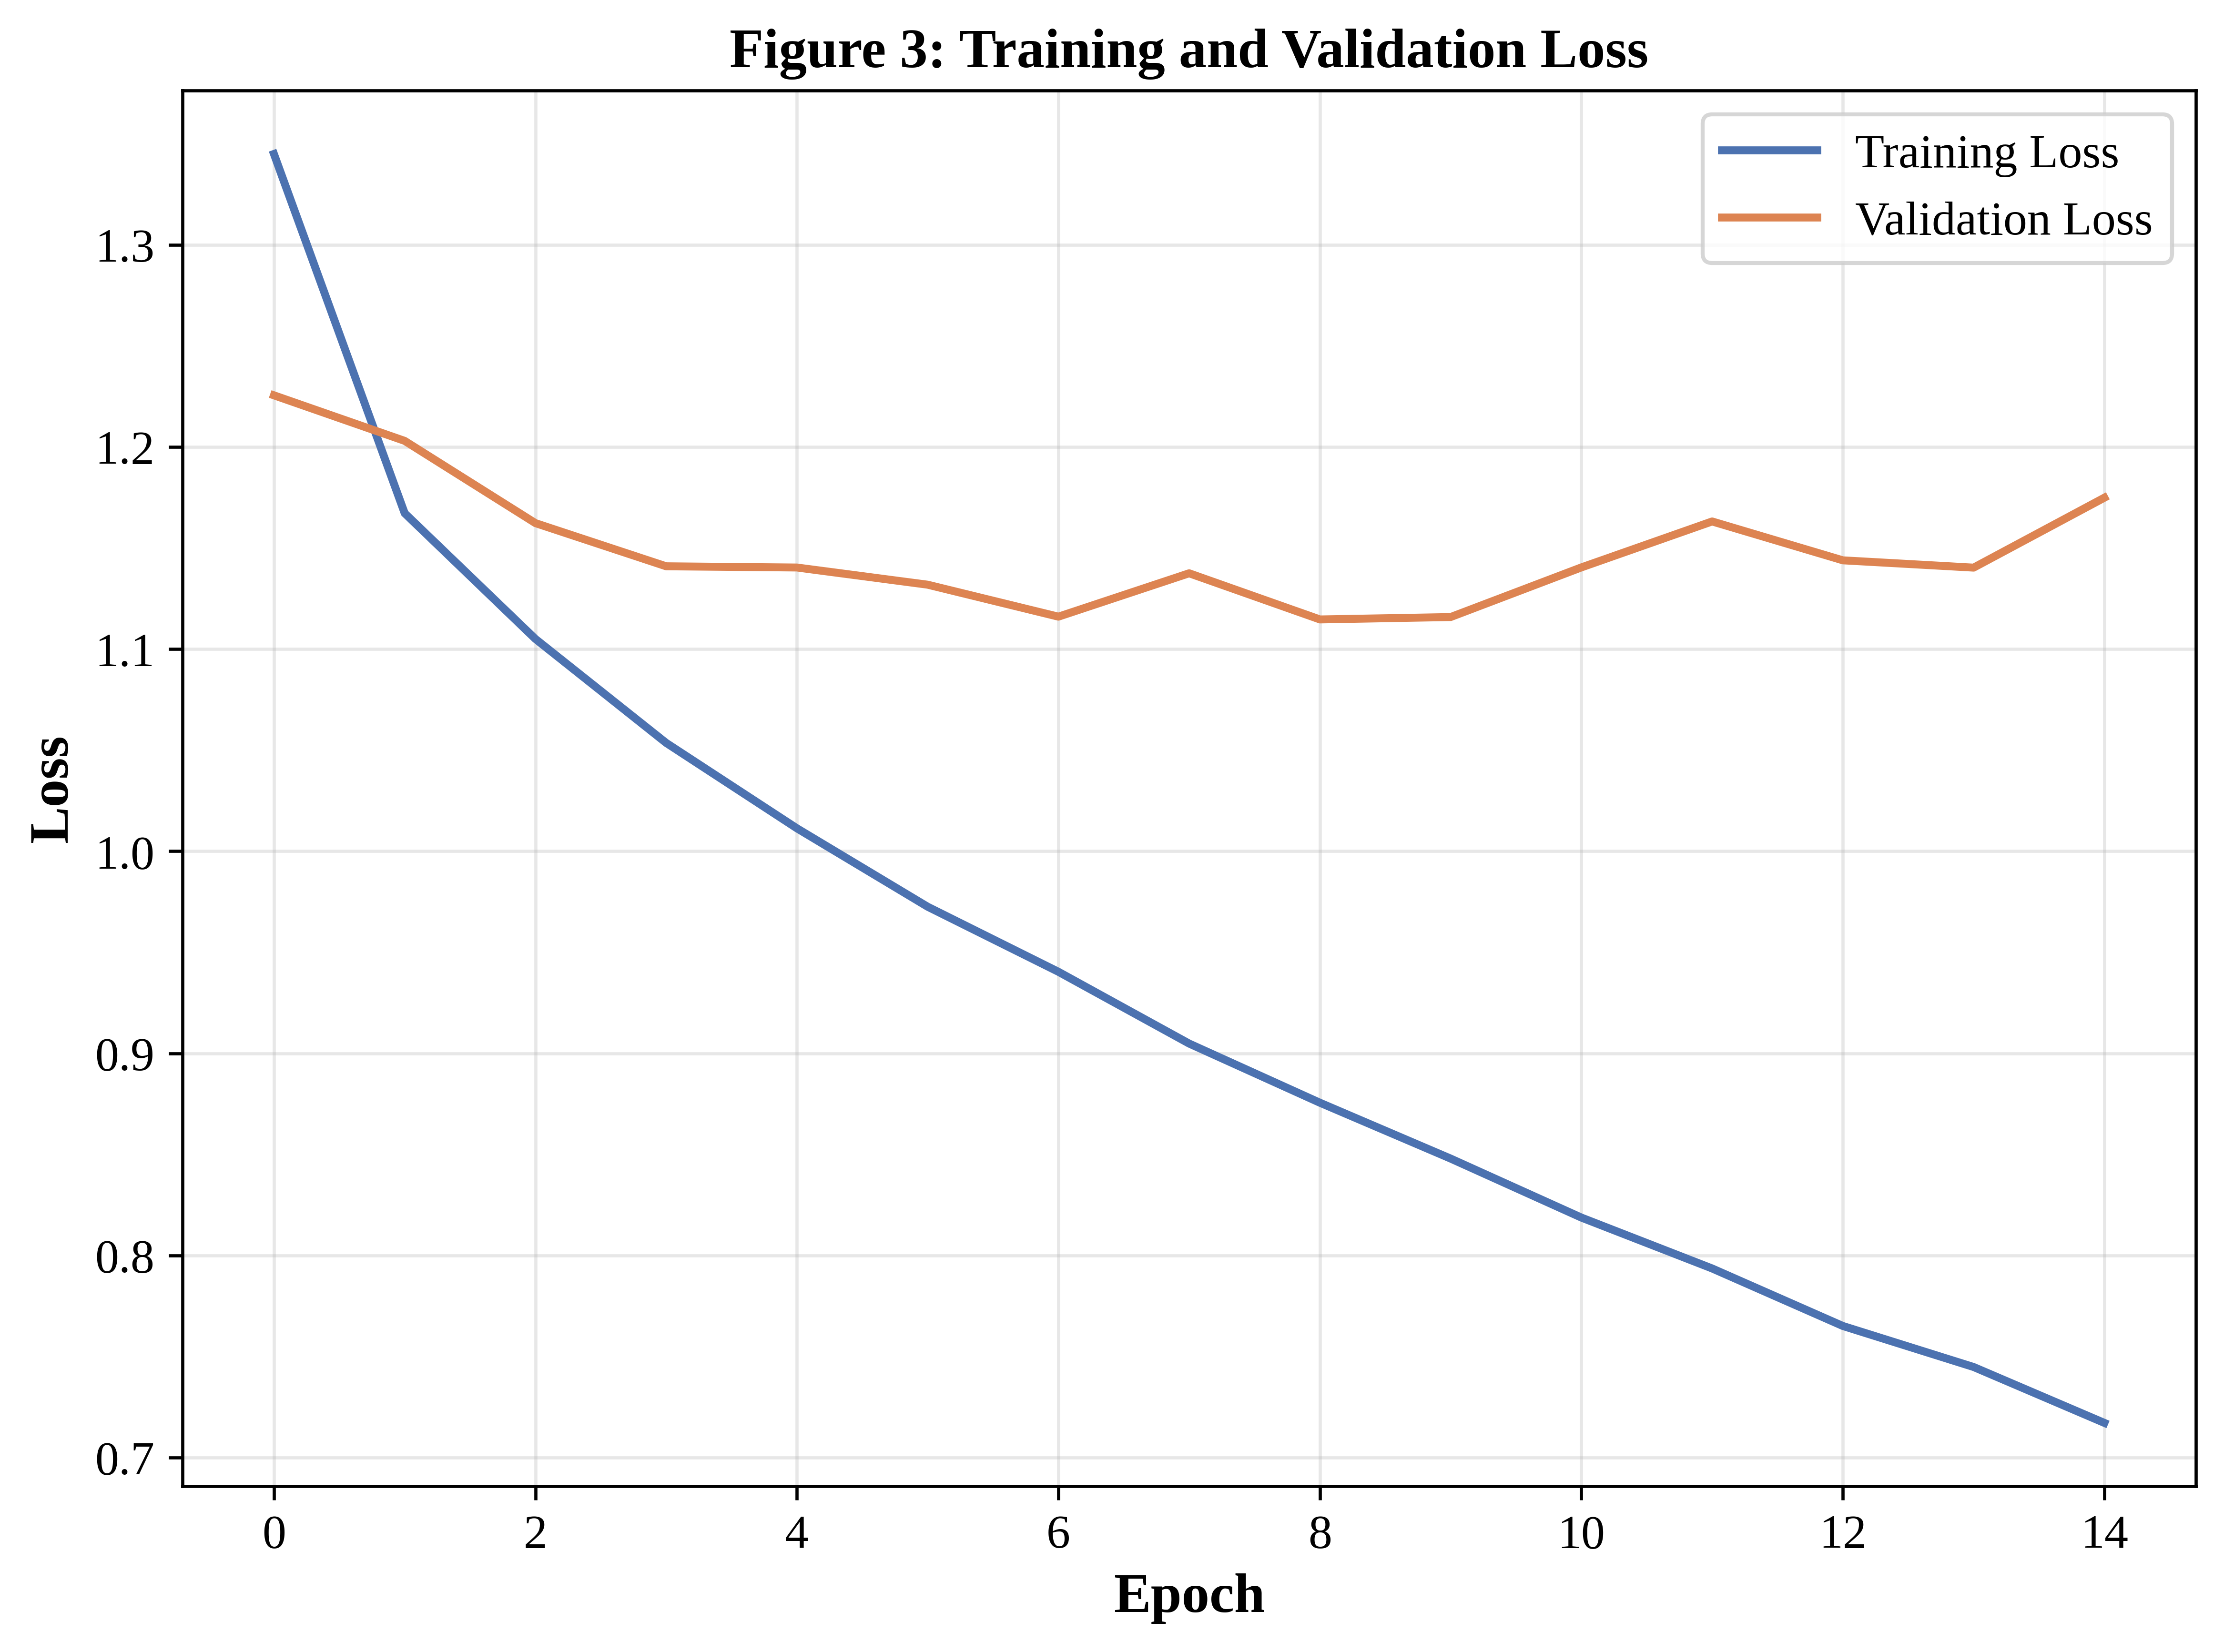


Caption — Figure 3: Training and Validation Loss vs Epochs
Inference: Both losses decrease consistently across epochs, showing stable convergence of the classifier head trained on frozen VGG16 features.


In [6]:
# Figures 2 & 3: Training/Validation Accuracy and Loss
# Figure 2 - Accuracy
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2, color='#4C72B0')
ax.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, color='#DD8452')
ax.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Figure 2: Training and Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(prop={'size': 12})
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 'fig2_accuracy')
plt.show()

print("\nCaption — Figure 2: Training and Validation Accuracy vs Epochs")
print("Inference: Training accuracy increases steadily while validation accuracy "
      "trends closely with it, indicating the pretrained features generalize well "
      "without severe overfitting.")

# Figure 3 - Loss
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(history.history['loss'], label='Training Loss', linewidth=2, color='#4C72B0')
ax.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, color='#DD8452')
ax.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax.set_ylabel('Loss', fontsize=14, fontweight='bold')
ax.set_title('Figure 3: Training and Validation Loss', fontsize=14, fontweight='bold')
ax.legend(prop={'size': 12})
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 'fig3_loss')
plt.show()

print("\nCaption — Figure 3: Training and Validation Loss vs Epochs")
print("Inference: Both losses decrease consistently across epochs, showing stable "
      "convergence of the classifier head trained on frozen VGG16 features.")

In [7]:
# Task 4: Fine Tuning
# Unfreeze the last convolution block of VGG16 (block5)
base_model.trainable = True
for layer in base_model.layers:
    if not layer.name.startswith('block5'):
        layer.trainable = False

model.compile(optimizer=Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

start_ft_time = time.time()

history_ft = model.fit(
    x_train_norm, y_train_cat,
    validation_data=(x_test_norm, y_test_cat),
    batch_size=32,
    epochs=10,
    verbose=1
)

fine_tune_time = time.time() - start_ft_time
print(f"\nFine-tuning Time: {fine_tune_time:.2f} seconds ({fine_tune_time/60:.2f} minutes)")

total_training_time = training_time + fine_tune_time
print(f"Total Training Time (base + fine-tune): {total_training_time:.2f} seconds")

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 7,213,322 (27.52 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.6409 - loss: 1.0326 - val_accuracy: 0.6779 - val_loss: 0.9447
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7266 - loss: 0.7774 - val_accuracy: 0.7118 - val_loss: 0.8525
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.7690 - loss: 0.6476 - val_accuracy: 0.7206 - val_loss: 0.8326
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8088 - loss: 0.5359 - val_accuracy: 0.7331 - val_loss: 0.8112
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8426 - loss: 0.4347 - val_accuracy: 0.7297 - val_loss: 0.8558
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.8736 - loss: 0.3496 - val_accuracy: 0.7397 - val_loss: 0.9014
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9037 - loss: 0.2706 - val_accuracy: 0.7377 - val_loss: 0.9776
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9252 -

Saved: figures/fig4_finetune_accuracy.eps and figures/fig4_finetune_accuracy.pdf


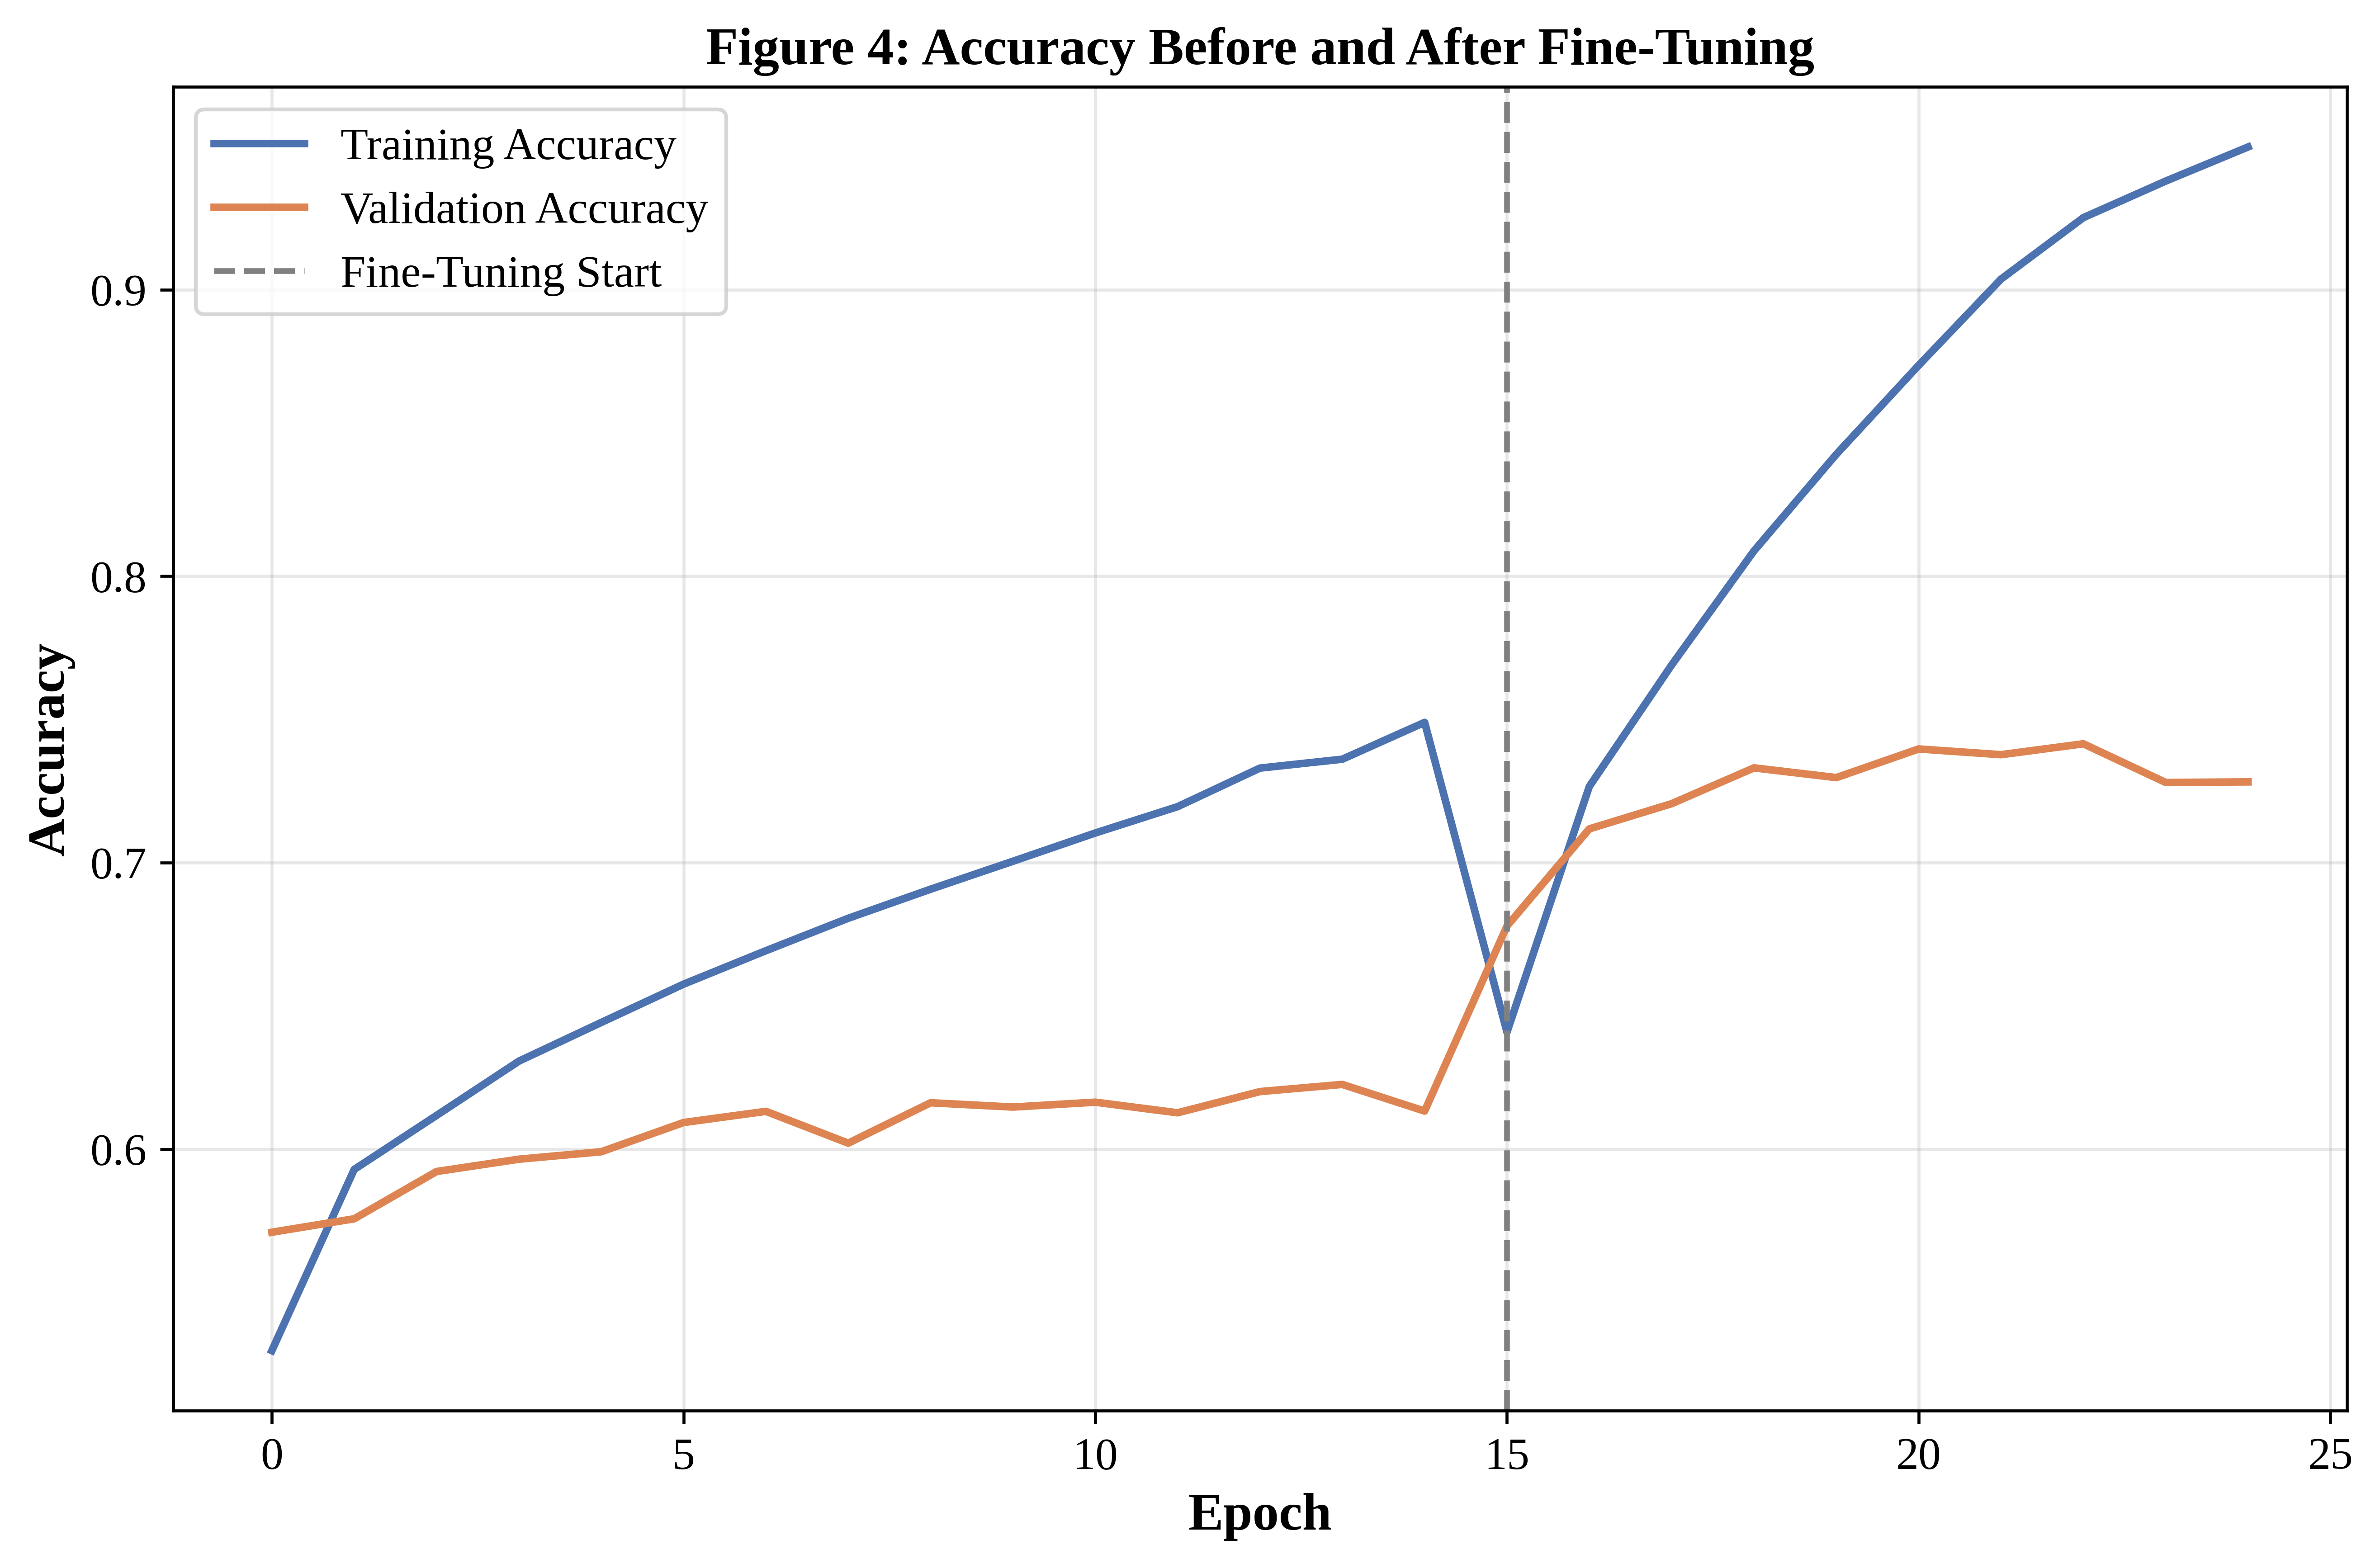


Caption — Figure 4: Accuracy Before and After Fine-Tuning
Inference: Accuracy improves further after unfreezing block5, showing that fine-tuning the last convolutional block adapts high-level features better to CIFAR-10's low-resolution domain.


In [8]:
# Combined Accuracy/Loss Before vs After Fine-Tuning
# Combine histories for a full picture across both training phases
combined_acc = history.history['accuracy'] + history_ft.history['accuracy']
combined_val_acc = history.history['val_accuracy'] + history_ft.history['val_accuracy']
combined_loss = history.history['loss'] + history_ft.history['loss']
combined_val_loss = history.history['val_loss'] + history_ft.history['val_loss']
ft_start_epoch = len(history.history['accuracy'])

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(combined_acc, label='Training Accuracy', linewidth=2, color='#4C72B0')
ax.plot(combined_val_acc, label='Validation Accuracy', linewidth=2, color='#DD8452')
ax.axvline(x=ft_start_epoch, color='gray', linestyle='--', linewidth=1.5, label='Fine-Tuning Start')
ax.set_xlabel('Epoch', fontsize=14, fontweight='bold')
ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold')
ax.set_title('Figure 4: Accuracy Before and After Fine-Tuning', fontsize=14, fontweight='bold')
ax.legend(prop={'size': 12})
ax.grid(alpha=0.3)
plt.tight_layout()
save_fig(fig, 'fig4_finetune_accuracy')
plt.show()

print("\nCaption — Figure 4: Accuracy Before and After Fine-Tuning")
print("Inference: Accuracy improves further after unfreezing block5, showing that "
      "fine-tuning the last convolutional block adapts high-level features better "
      "to CIFAR-10's low-resolution domain.")

In [9]:
# Task 5: Model Evaluation
y_pred_probs = model.predict(x_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

test_accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Testing Accuracy : {test_accuracy*100:.2f}%")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-score         : {f1:.4f}")
print(f"Total Parameters : {total_params:,}")
print(f"Total Training Time: {total_training_time:.2f} seconds")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Testing Accuracy : 72.82%
Precision        : 0.7328
Recall           : 0.7282
F1-score         : 0.7277
Total Parameters : 14,848,586
Total Training Time: 445.19 seconds

Classification Report:
              precision    recall  f1-score   support

    Airplane       0.79      0.74      0.77      1000
  Automobile       0.82      0.85      0.83      1000
        Bird       0.57      0.78      0.66      1000
         Cat       0.60      0.49      0.54      1000
        Deer       0.66      0.69      0.68      1000
         Dog       0.66      0.60      0.63      1000
        Frog       0.78      0.76      0.77      1000
       Horse       0.78      0.78      0.78      1000
        Ship       0.85      0.85      0.85      1000
       Truck       0.82      0.73      0.78      1000

    accuracy                           0.73     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.73      0.73      0.73     10000



Saved: figures/fig5_confusion_matrix.eps and figures/fig5_confusion_matrix.pdf


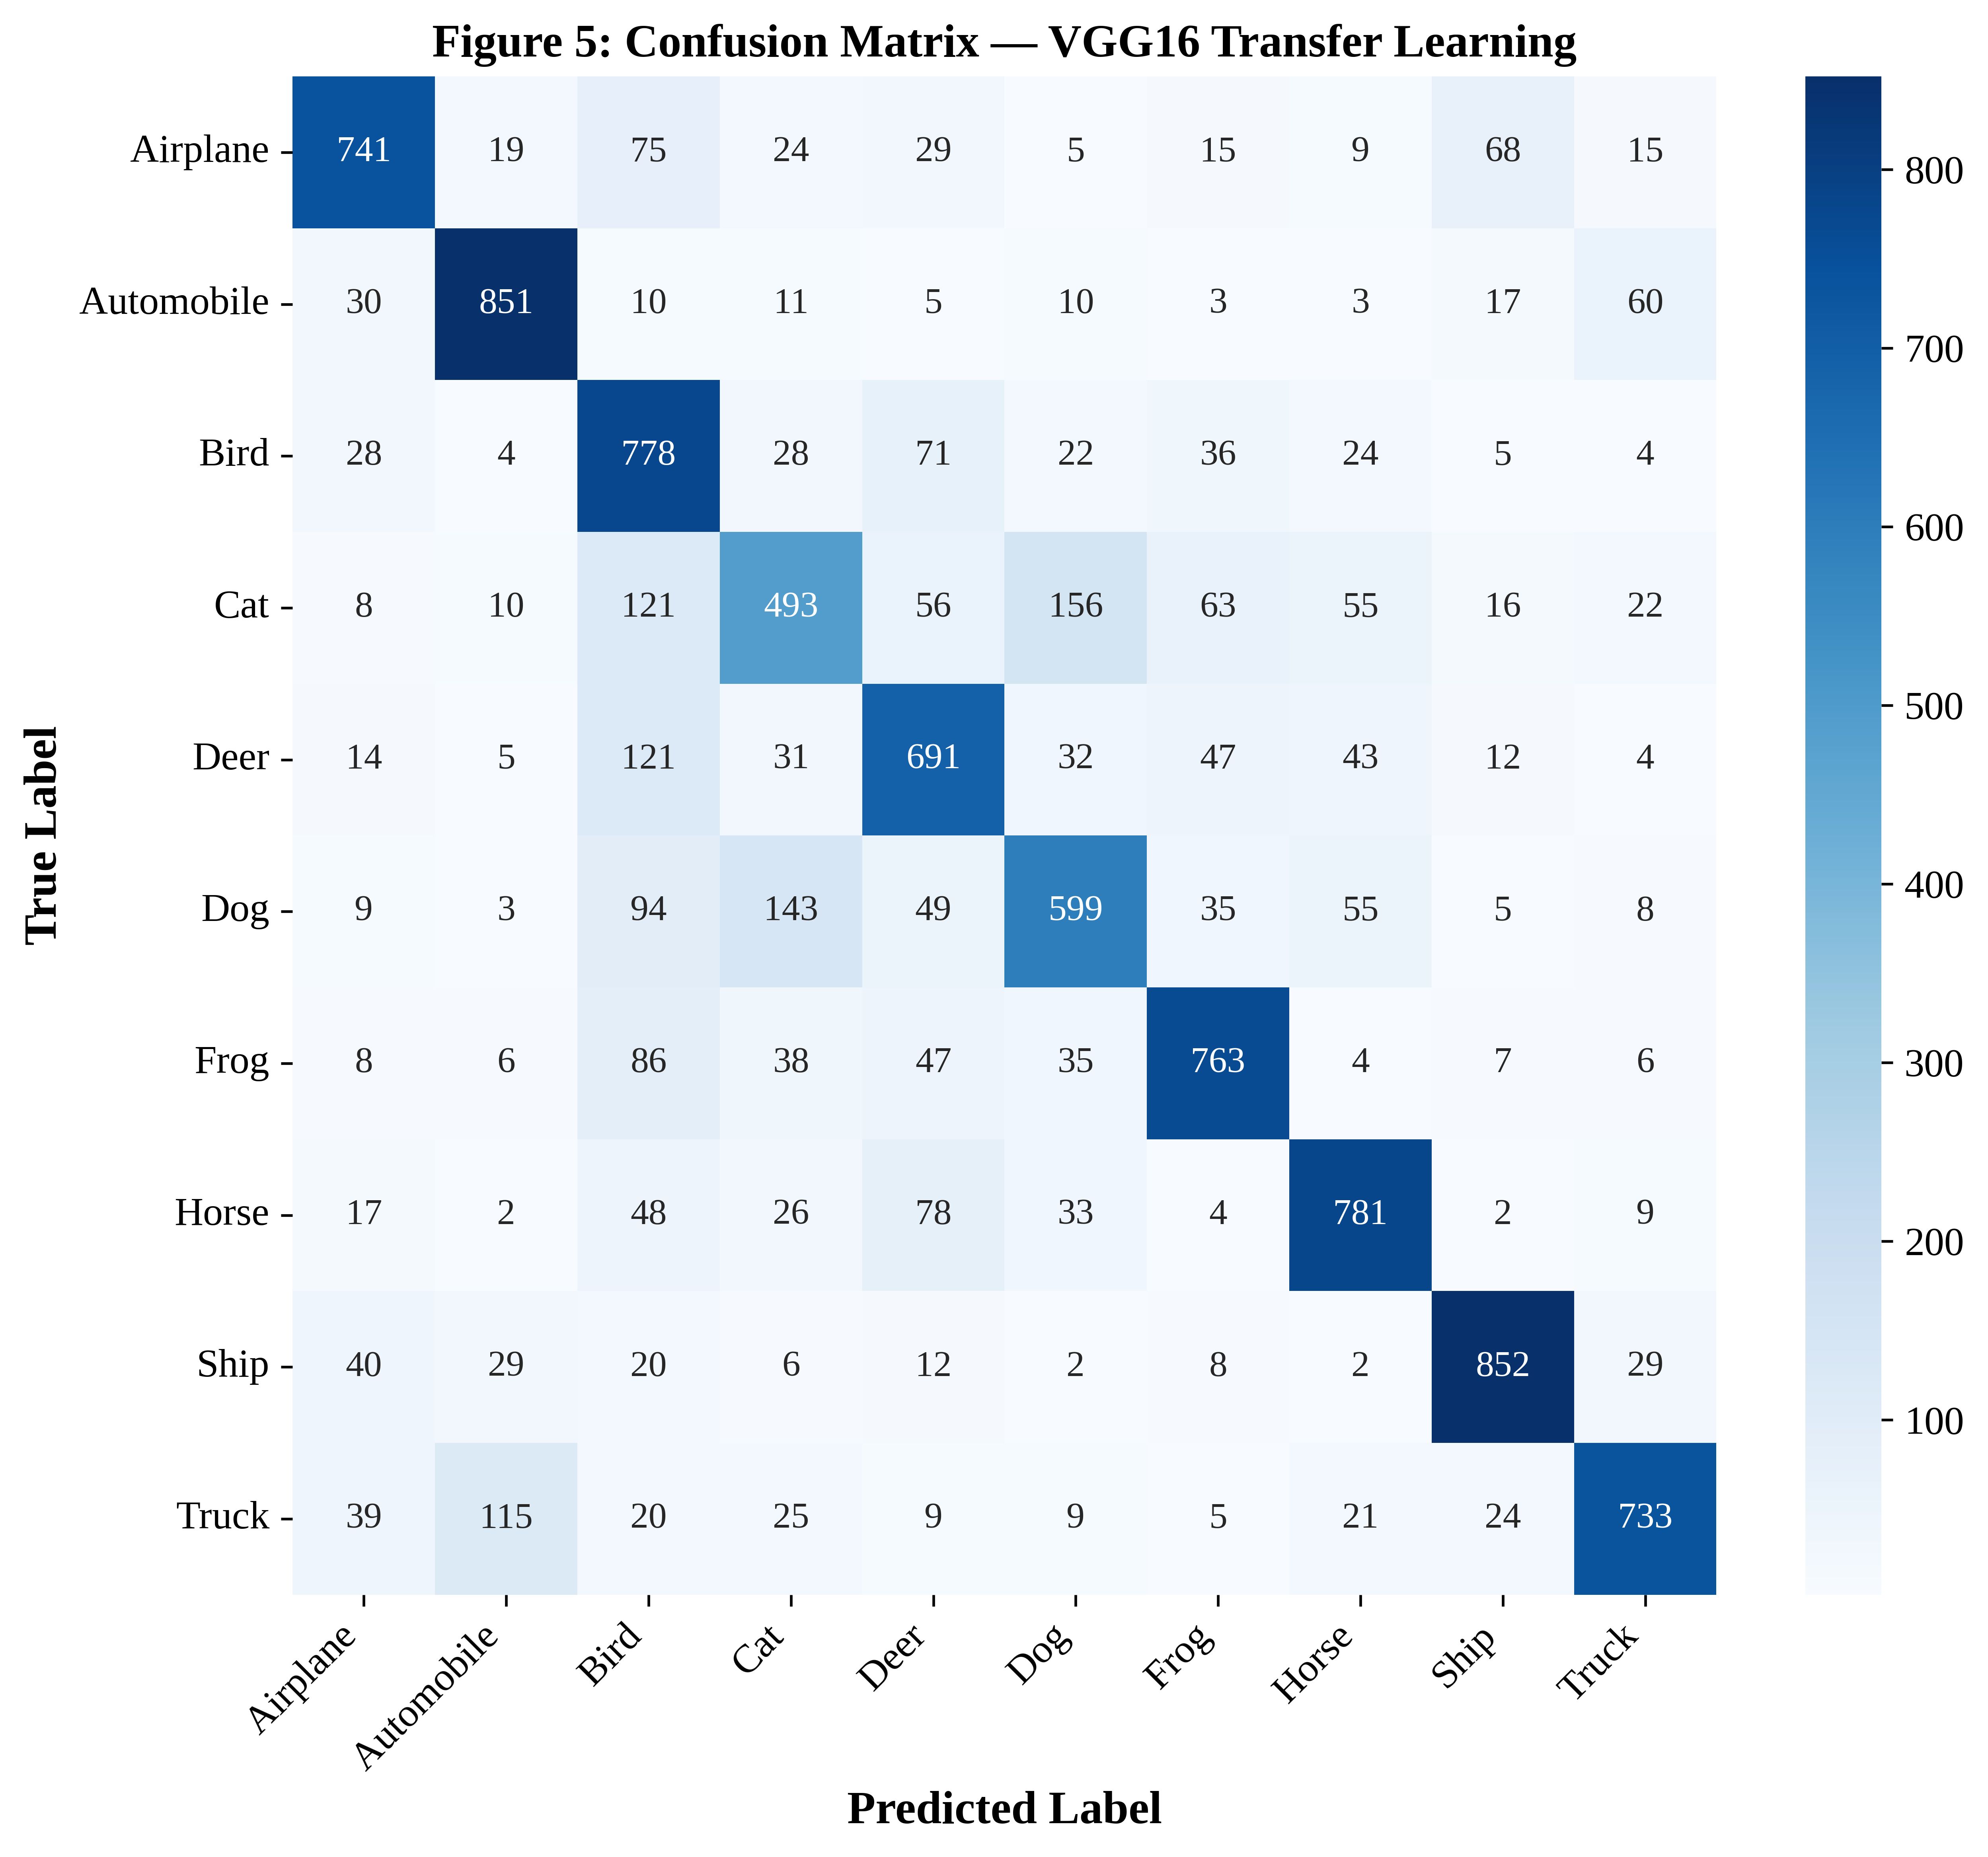


Caption — Figure 5: Confusion Matrix for Test Set Predictions
Inference: Most misclassifications occur among visually similar animal classes (e.g., Cat/Dog, Deer/Horse), while distinct classes like Automobile and Ship show high diagonal dominance.


In [10]:
# Figure 5: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            annot_kws={"size": 11}, ax=ax, cbar=True)
ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
ax.set_title('Figure 5: Confusion Matrix — VGG16 Transfer Learning', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_fig(fig, 'fig5_confusion_matrix')
plt.show()

print("\nCaption — Figure 5: Confusion Matrix for Test Set Predictions")
print("Inference: Most misclassifications occur among visually similar animal classes "
      "(e.g., Cat/Dog, Deer/Horse), while distinct classes like Automobile and Ship "
      "show high diagonal dominance.")

Saved: figures/fig6_misclassified.eps and figures/fig6_misclassified.pdf


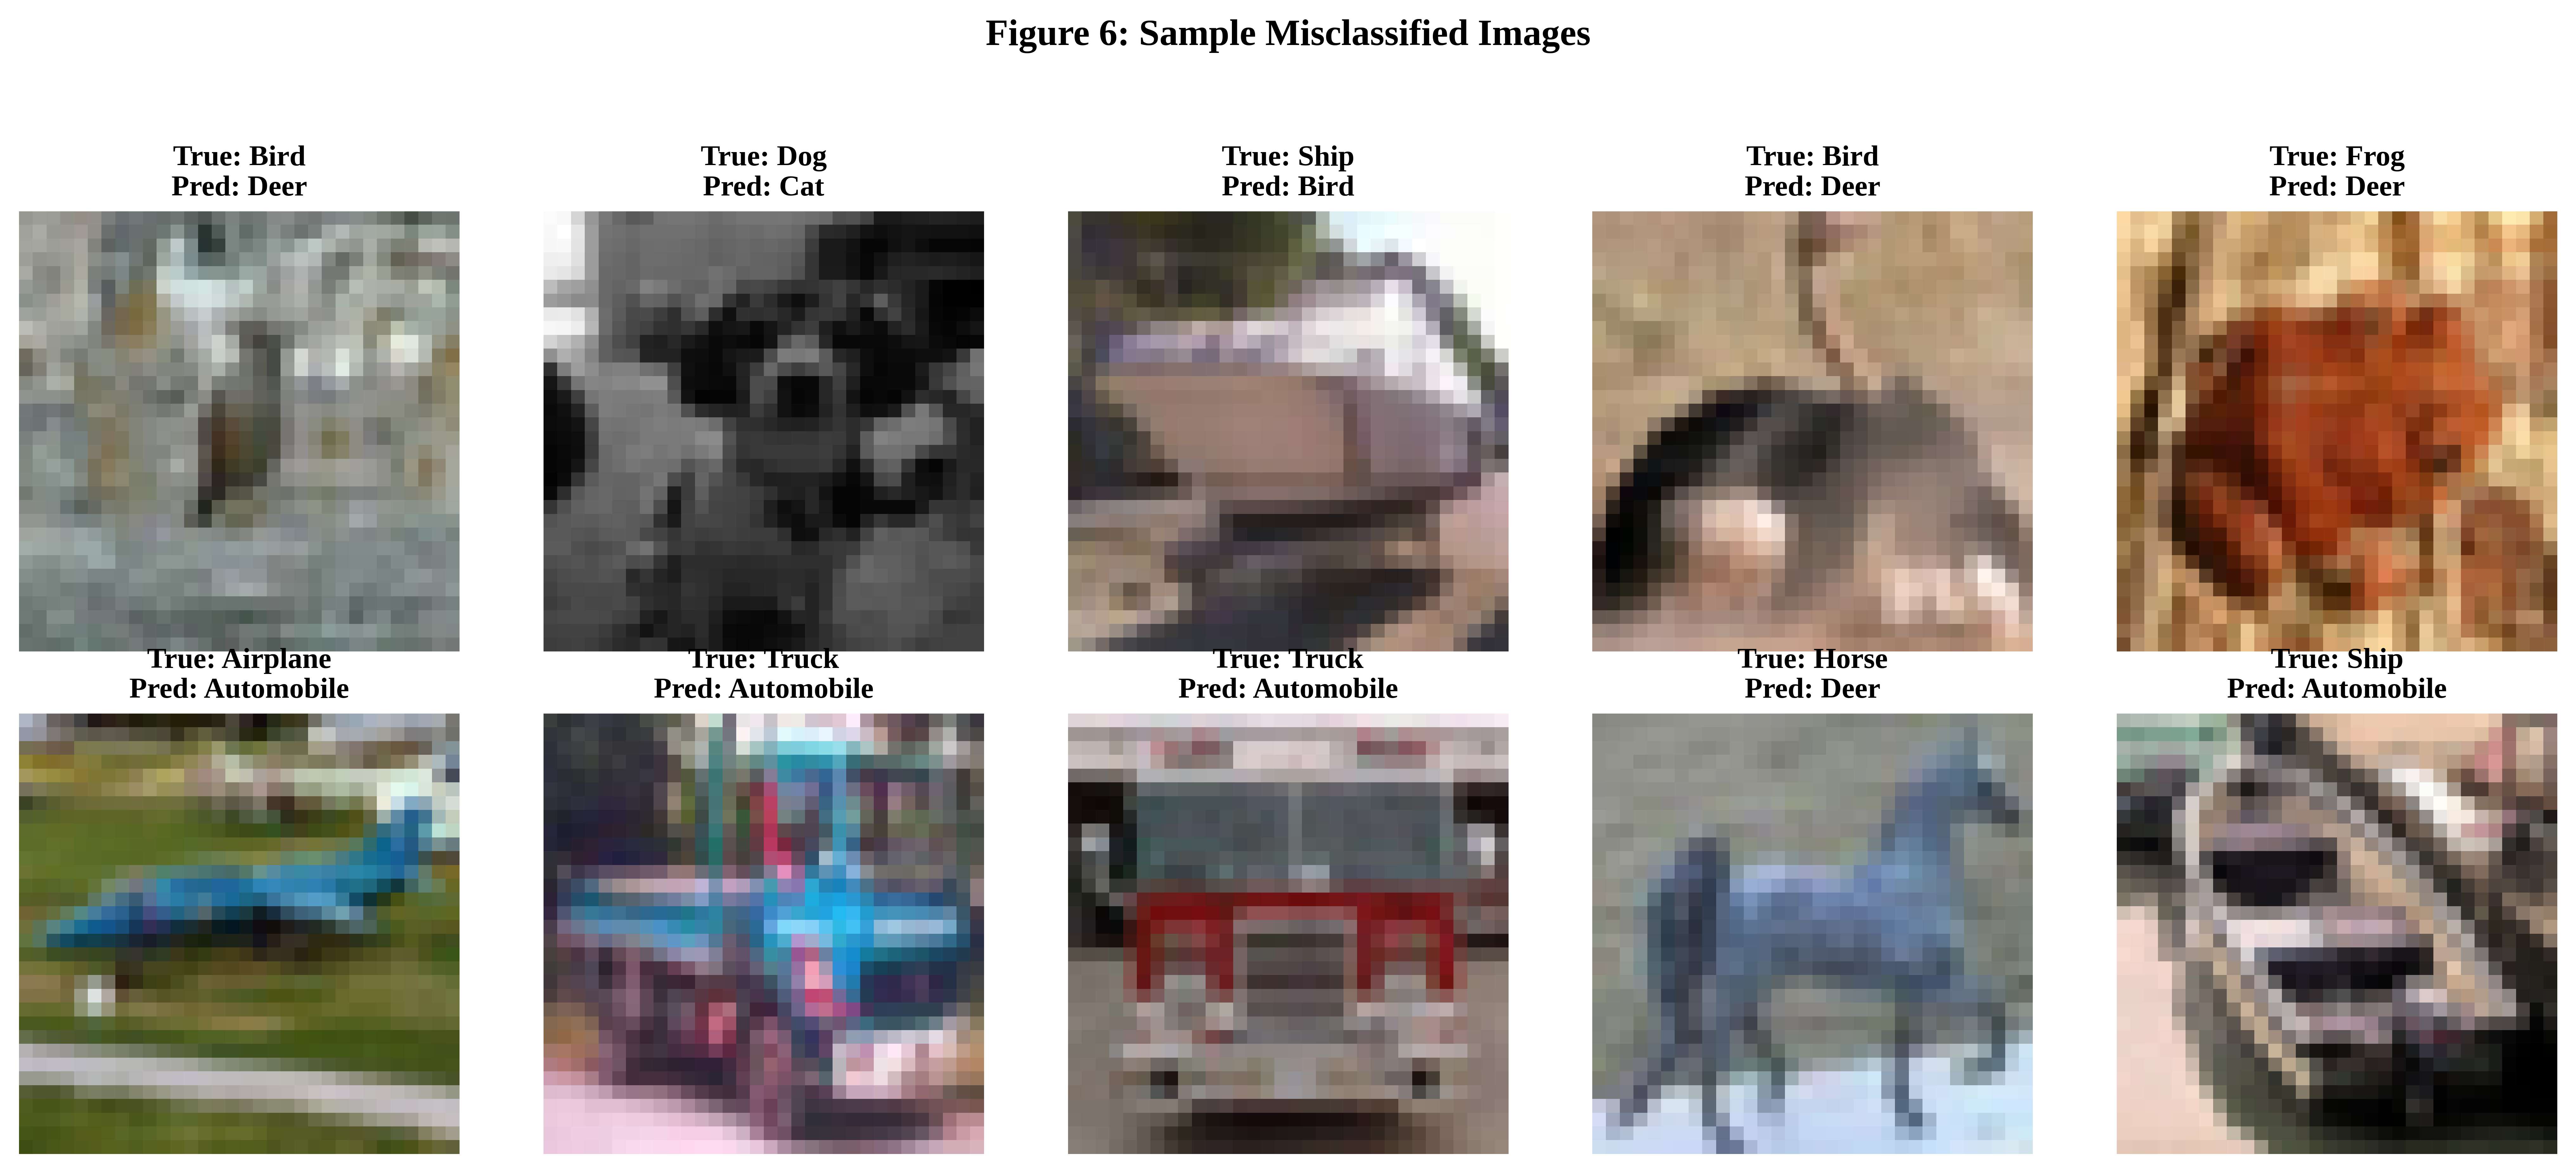


Caption — Figure 6: Misclassified Test Images
Inference: Errors are concentrated in fine-grained animal categories where low-resolution 32x32 images lose distinguishing texture and shape cues.


In [11]:
# Figure 6 (Optional): Misclassified Images
misclassified_idx = np.where(y_pred != y_true)[0]
sample_idx = np.random.choice(misclassified_idx, size=10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    idx = sample_idx[i]
    ax.imshow(x_test[idx])
    ax.set_title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}",
                 fontsize=11, fontweight='bold')
    ax.axis('off')

fig.suptitle('Figure 6: Sample Misclassified Images', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
save_fig(fig, 'fig6_misclassified')
plt.show()

print("\nCaption — Figure 6: Misclassified Test Images")
print("Inference: Errors are concentrated in fine-grained animal categories where "
      "low-resolution 32x32 images lose distinguishing texture and shape cues.")

In [12]:
# Hyperparameter Study (Optional, Section 16)
hyperparam_results = []

configs = [
    {'lr': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'dense_units': 256},
    {'lr': 0.0001, 'batch_size': 32, 'optimizer': 'adam', 'dense_units': 256},
    {'lr': 0.001, 'batch_size': 64, 'optimizer': 'sgd', 'dense_units': 128},
]

for cfg in configs:
    base = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
    base.trainable = False
    x = GlobalAveragePooling2D()(base.output)
    x = Dense(cfg['dense_units'], activation='relu')(x)
    out = Dense(10, activation='softmax')(x)
    m = Model(inputs=base.input, outputs=out)

    opt = Adam(learning_rate=cfg['lr']) if cfg['optimizer'] == 'adam' else tf.keras.optimizers.SGD(learning_rate=cfg['lr'])
    m.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    t0 = time.time()
    h = m.fit(x_train_norm, y_train_cat, validation_data=(x_test_norm, y_test_cat),
              batch_size=cfg['batch_size'], epochs=5, verbose=0)
    elapsed = time.time() - t0

    val_acc = h.history['val_accuracy'][-1]
    hyperparam_results.append({**cfg, 'val_accuracy': val_acc, 'time_sec': elapsed})
    print(f"Config {cfg} -> Val Accuracy: {val_acc:.4f}, Time: {elapsed:.1f}s")

import pandas as pd
df_results = pd.DataFrame(hyperparam_results)
print("\n", df_results)

Config {'lr': 0.001, 'batch_size': 32, 'optimizer': 'adam', 'dense_units': 256} -> Val Accuracy: 0.6090, Time: 81.3s
Config {'lr': 0.0001, 'batch_size': 32, 'optimizer': 'adam', 'dense_units': 256} -> Val Accuracy: 0.5712, Time: 83.2s
Config {'lr': 0.001, 'batch_size': 64, 'optimizer': 'sgd', 'dense_units': 128} -> Val Accuracy: 0.3820, Time: 64.3s

        lr  batch_size optimizer  dense_units  val_accuracy   time_sec
0  0.0010          32      adam          256        0.6090  81.281761
1  0.0001          32      adam          256        0.5712  83.185358
2  0.0010          64       sgd          128        0.3820  64.311159


In [13]:
# Save Model & Download Figures
model.save('vgg16_cifar10_finetuned.keras')

# Zip all figures for download
!zip -r figures.zip figures/

from google.colab import files
files.download('figures.zip')

  adding: figures/ (stored 0%)
  adding: figures/fig5_confusion_matrix.eps (deflated 99%)
  adding: figures/fig4_finetune_accuracy.eps (deflated 63%)
  adding: figures/fig3_loss.eps (deflated 65%)
  adding: figures/fig4_finetune_accuracy.pdf (deflated 28%)
  adding: figures/fig6_misclassified.pdf (deflated 61%)
  adding: figures/fig2_accuracy.pdf (deflated 29%)
  adding: figures/fig6_misclassified.eps (deflated 98%)
  adding: figures/fig3_loss.pdf (deflated 28%)
  adding: figures/fig1_sample_images.eps (deflated 98%)
  adding: figures/fig1_sample_images.pdf (deflated 62%)
  adding: figures/fig2_accuracy.eps (deflated 65%)
  adding: figures/fig5_confusion_matrix.pdf (deflated 29%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>